In [1]:
"""
Quantum Error Correction and State Tomography on IBM Quantum Hardware.

This script demonstrates a 3-qubit PHASE-FLIP error correction code applied to a single logical qubit.
After injecting an error and dynamically correcting it, quantum state tomography is performed 
across the X, Y, and Z bases using Qiskit Runtime Service and SamplerV2.
"""

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.visualization import plot_histogram, plot_bloch_vector
import numpy as np
import matplotlib.pyplot as plt
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

In [2]:
# 1. IBM Quantum Authentication
# REPLACE 'YOUR_IBM_QUANTUM_API_TOKEN' WITH YOUR ACTUAL TOKEN
# You can get your API token from: https://quantum.ibm.com/
service = QiskitRuntimeService(channel="ibm_quantum_platform", token= "3iagZjBjX6KicSSO7nr8SlEkflCf_q6ttN2sUuKojJAv")

# 2. Backend Selection
backend = service.backend('ibm_fez')

qiskit_runtime_service._discover_account:WARNING:2026-05-28 17:59:54,895: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-05-28 18:00:00,812: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-05-28 18:00:00,812: Using instance: open-instance, plan: open


# Let's define a function that does the tomography of the state we want to analyse

In [3]:
# 3. Tomography Circuit Generator Function
def create_tomography_circuit(basis):
    """
    Generates a quantum circuit for error correction and measurement in a specific basis.
    
    Args:
        basis (str): The measurement basis ('X', 'Y', or 'Z').
        
    Returns:
        QuantumCircuit: The constructed quantum circuit.
    """
    q = QuantumRegister(3, 'q')
    c_syndrome = ClassicalRegister(2, 'syndrome')
    c_data = ClassicalRegister(1, 'data') 
    circ = QuantumCircuit(q, c_syndrome, c_data, name=f"tomo_{basis} phaseflip")

    # State initialization (Probabilities 3/4 and 1/4)
    theta = np.pi / 3
    circ.ry(theta, 0)

    # Logical encoding (3-qubit bit-flip code)
    circ.cx(0, 1)
    circ.cx(0, 2)
    circ.h(0)
    circ.h(1)
    circ.h(2)
    circ.barrier()

    # Error injection (Simulating a bit-flip on qubit 0)
    circ.z(0)
    circ.barrier()

    # Decoding
    circ.h(0)
    circ.h(1)
    circ.h(2)
    circ.cx(0, 1)
    circ.cx(0, 2)
    circ.barrier()

    # Syndrome measurement
    circ.measure([1, 2], c_syndrome) 

    # Conditional correction (Using Dynamic Circuits)
    with circ.if_test((c_syndrome, 3)):
        circ.x(0) 

    circ.barrier()

    # Basis preparation for tomography
    if basis == 'X':
        circ.h(0)
    elif basis == 'Y':
        circ.sdg(0)
        circ.h(0)
    # No additional gates are needed for the Z-basis

    # Final data measurement
    circ.measure([0], c_data)     
    
    return circ

In [4]:
# 4. Create circuits for Z, X, and Y basis
bases = ['Z', 'X', 'Y']
circuits = [create_tomography_circuit(b) for b in bases]

# 5. Transpilation
# 5. Transpilation using Pass Manager
print("Transpiling circuits for ISA...")
pm = generate_preset_pass_manager(backend=backend)
t_circuits = pm.run(circuits)


# 6. Execution using SamplerV2
print("Sending job to IBM Quantum queue...")
sampler = Sampler(mode=backend)

# Send all 3 circuits in a single batch to avoid waiting in the queue multiple times
job = sampler.run(t_circuits, shots=8192)
print(f"Job successfully submitted. Job ID: {job.job_id()}")
print("Waiting for results (this may take a while depending on queue times)...")

# Execution will pause here until the job finishes
result = job.result()

# 7. Result Extraction
for idx, basis in enumerate(bases):
    # In Qiskit Runtime V2, results are grouped by classical register names.
    # We extract the 'data' register which holds the measurement of our corrected qubit.
    pub_result = result[idx]
    data_counts = pub_result.data.data.get_counts()
    
    print(f"\n--- {basis}-Basis Tomography Results ---")
    print(f"Data qubit counts: {data_counts}")
    
# Optional: Uncomment the following lines if running in a Jupyter Notebook to visualize
# from qiskit.visualization import plot_histogram
# plot_histogram(result[0].data.data.get_counts(), title="Z-Basis Tomography (Real Hardware)")

Transpiling circuits for ISA...
Sending job to IBM Quantum queue...
Job successfully submitted. Job ID: d8c6d1b8amns73bj2ce0
Waiting for results (this may take a while depending on queue times)...

--- Z-Basis Tomography Results ---
Data qubit counts: {'0': 5684, '1': 2508}

--- X-Basis Tomography Results ---
Data qubit counts: {'1': 1033, '0': 7159}

--- Y-Basis Tomography Results ---
Data qubit counts: {'0': 4504, '1': 3688}


Coordinates of the Bloch Vector [X, Y, Z]:
X: 0.748
Y: 0.100
Z: 0.388


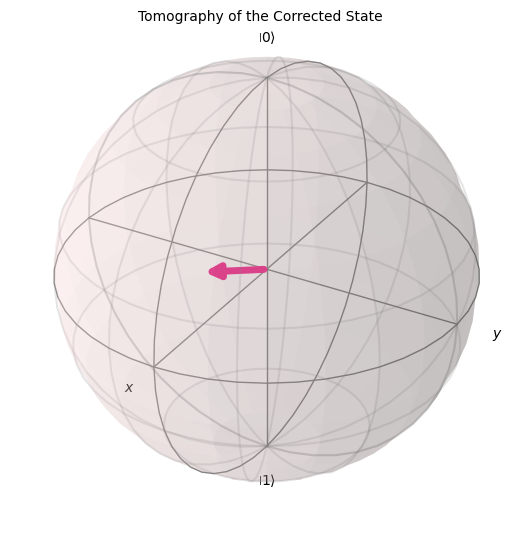

In [5]:
# 2. State Reconstruction
exp_values = {}
bases = ['Z', 'X', 'Y']
for idx, basis in enumerate(bases):
    # Counts extraction for the data qubit
    counts = result[idx].data.data.get_counts()
    
    # Calculating total shots
    total_shots = sum(counts.values())
    
    # Calculating the probability of measuring 0 and 1
    p0 = counts.get('0', 0) / total_shots
    p1 = counts.get('1', 0) / total_shots
    
    # Expected value calculation: <O> = P(0) - P(1)
    exp_values[basis] = p0 - p1
# Create the 3D vector with coordinates [X, Y, Z]
bloch_coords = [exp_values['X'], exp_values['Y'], exp_values['Z']]
mean_value = np.array(bloch_coords)
print(f"Coordinates of the Bloch Vector [X, Y, Z]:")
print(f"X: {bloch_coords[0]:.3f}")
print(f"Y: {bloch_coords[1]:.3f}")
print(f"Z: {bloch_coords[2]:.3f}")

# 3. Drawing the Tomography
plot_bloch_vector(bloch_coords, title="Tomography of the Corrected State")

In [6]:
# 2. Proocessing and Plotting
for idx, basis in enumerate(basis):
    pub_result = result[idx]
    
    # Extracting both 'data' and 'syndrome' bitstrings
    data_bits = pub_result.data.data.get_bitstrings()
    syndrome_bits = pub_result.data.syndrome.get_bitstrings()
    
    # Combining data and syndrome bits into a single dictionary for histogram plotting
    combined_counts = {}
    for d, s in zip(data_bits, syndrome_bits):
        key = f"{d} {s}"
        combined_counts[key] = combined_counts.get(key, 0) + 1
        
    print(f"\n--- Conteos combinados Base {basis} ---")
    print(combined_counts)
    
    # 3. Generating and Saving the Histogram
    fig = plot_histogram(
        combined_counts, 
        title=f"Tomography for phase-flip code on real hardware ({basis}-basis)",
        figsize=(6, 5)
    )
    
    fig.savefig(f"Tomography_comp_{basis}_real_phaseflip.png")


--- Conteos combinados Base Y ---
{'0 11': 5481, '1 11': 2138, '0 10': 57, '1 10': 125, '1 01': 230, '0 01': 116, '0 00': 30, '1 00': 15}


In [7]:
def plot_combined_tomography_results(job_result, bases=['Z', 'X', 'Y']):
    """
    Processes SamplerV2 results and generates combined histograms 
    (Data + Syndrome) for quantum state tomography.
    
    This function rebuilds the legacy format (e.g., "0 11") by combining 
    the bitstrings of the 'data' and 'syndrome' classical registers 
    shot by shot, allowing direct comparison with noise model simulations.
    
    Args:
        job_result (PrimitiveResult): The result object returned by SamplerV2.
        bases (list): A list of strings representing the measurement bases.
    """
    for idx, basis in enumerate(bases):
        # Extract the PubResult for the corresponding measurement basis
        pub_result = job_result[idx]
        
        # Retrieve the array of individual shots (bitstrings) for each register
        data_bits = pub_result.data.data.get_bitstrings()
        syndrome_bits = pub_result.data.syndrome.get_bitstrings()
        
        # Combine the bitstrings shot by shot into a single dictionary
        combined_counts = {}
        for data_val, syndrome_val in zip(data_bits, syndrome_bits):
            # Format: "data syndrome" (e.g., "0 11")
            key = f"{data_val} {syndrome_val}"
            combined_counts[key] = combined_counts.get(key, 0) + 1
            
        print(f"\n--- Combined Counts for {basis}-Basis ---")
        print(combined_counts)
        
        # Generate the classical Qiskit histogram
        fig = plot_histogram(
            combined_counts, 
            title=f"Tomography on Real Hardware for phase-flip code ({basis}-basis)",
            figsize=(8, 6)
        )
        
        # Save the figure to the current working directory to match previous noise graphs
        filename = f"Tomography_comp_{basis}_real_phaseflip.png"
        fig.savefig(filename, bbox_inches='tight')
        print(f"Figure successfully saved as: {filename}")

# =====================================================================
# Execution
# =====================================================================
# Since the job was previously opened and the results are stored in the 
# 'result' variable, we simply call the function passing this variable.

plot_combined_tomography_results(result)


--- Combined Counts for Z-Basis ---
{'0 11': 5481, '1 11': 2138, '0 10': 57, '1 10': 125, '1 01': 230, '0 01': 116, '0 00': 30, '1 00': 15}
Figure successfully saved as: Tomography_comp_Z_real_phaseflip.png

--- Combined Counts for X-Basis ---
{'1 11': 876, '0 11': 6718, '0 10': 139, '0 01': 275, '1 00': 26, '1 01': 82, '0 00': 27, '1 10': 49}
Figure successfully saved as: Tomography_comp_X_real_phaseflip.png

--- Combined Counts for Y-Basis ---
{'0 11': 4231, '1 11': 3348, '1 10': 120, '1 00': 23, '0 01': 149, '0 10': 103, '0 00': 21, '1 01': 197}
Figure successfully saved as: Tomography_comp_Y_real_phaseflip.png


# Fidelity calculation for real hardware simulation

In [8]:
shots = 8192

print(f"Mean value for Z component: {mean_value[2]}")
print(f"Mean value for X component: {mean_value[0]}")
print(f"Mean value for Y component: {mean_value[1]}")

# Verify probability conservation
prob = mean_value[0] ** 2 + mean_value[1] ** 2 + mean_value[2] ** 2
print(f"Probability conservation (should be close to 1.0): {prob}")

# Plot the Bloch vector
vector = np.array([mean_value[0], mean_value[1], mean_value[2]])
plot_bloch_vector(vector, title='Bloch vector for the corrected state')


# Density matrix reconstruction from the measured Bloch vector components
rho_reconstructed = 0.5 * (
    np.eye(2) +
    mean_value[0] * np.array([[0,1],[1,0]]) +
    mean_value[1] * np.array([[0,-1j],[1j,0]]) +
    mean_value[2] * np.array([[1,0],[0,-1]])
)

# Ideal state as a density matrix vector
ideal = np.array([np.sqrt(3)/2, 1/2])
rho_ideal = np.outer(ideal, ideal)

# Fidelity F = Tr(rho_ideal @ rho_reconstructed)
fidelity = np.real(np.trace(rho_ideal @ rho_reconstructed))
print(f"Fidelity reconstructed: {fidelity:.6f}")

Mean value for Z component: 0.3876953125
Mean value for X component: 0.747802734375
Mean value for Y component: 0.099609375
Probability conservation (should be close to 1.0): 0.7194386124610901
Fidelity reconstructed: 0.920732
